In [60]:
# Get the data and examine it

In [61]:
import pandas as pd
tsa = pd.read_csv(
    r"C:\Users\misht\Downloads\tsa_claims2.csv"
)

tsa.head()

C:\Users\misht\AppData\Local\Temp\ipykernel_21552\2203393067.py:2: DtypeWarning: Columns (0,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  tsa = pd.read_csv(


,Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,$350.00,Approved,$350.00,Approve in Full
1,0202417M,2-Feb-02,1/16/2004 0:00,SEA,Seattle-Tacoma International,NaN,Property Damage,Checked Baggage,Luggage (all types including footlockers),$100.00,Settled,$50.00,Settle
2,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,$278.88,Settled,$227.92,Settle
3,0909816M,7-Feb-02,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),$50.00,Approved,$50.00,Approve in Full
4,2005032379513,18-Feb-02,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,$84.79,Approved,$84.79,Approve in Full


In [62]:
tsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204267 entries, 0 to 204266
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Claim Number   204267 non-null  object
 1   Date Received  204004 non-null  object
 2   Incident Date  202084 non-null  object
 3   Airport Code   195743 non-null  object
 4   Airport Name   195743 non-null  object
 5   Airline Name   169893 non-null  object
 6   Claim Type     196354 non-null  object
 7   Claim Site     203527 non-null  object
 8   Item           200301 non-null  object
 9   Claim Amount   200224 non-null  object
 10  Status         204262 non-null  object
 11  Close Amount   135315 non-null  object
 12  Disposition    131359 non-null  object
dtypes: object(13)
memory usage: 20.3+ MB


#I am examining data before cleaning:
Date formats are different in Date Received and Incident Date Claim amount and Close amount has dollar sign, data type is object instead of float

# Inspecting before cleaning

In [63]:
tsa["Claim Type"].value_counts()

Claim Type
Passenger Property Loss    117868
Property Damage             75364
Personal Injury              1465
Employee Loss (MPCECA)        485
Passenger Theft               465
Motor Vehicle                 369
-                             282
Complaint                      48
Wrongful Death                  4
Compliment                      3
Bus Terminal                    1
Name: count, dtype: int64

#Passenger Property Loss: the most common claim type.
"-" that may represent missing or invalid data.

In [64]:
tsa["Claim Site"].value_counts()

Claim Site
Checked Baggage    159753
Checkpoint          40133
Other                2875
Motor Vehicle         474
-                     276
Bus Station            16
Name: count, dtype: int64

#Checked baggage: the most common claim site.
"-" that may represent missing or invalid data

In [65]:
tsa["Disposition"].value_counts()

Disposition
Deny               68382
Approve in Full    35010
Settle             27967
Name: count, dtype: int64

#deposition is categorical variable

# Drop all rows that contain NA values

In [66]:
#Check NA before dropping

In [67]:
tsa.isna().sum() 


Claim Number         0
Date Received      263
Incident Date     2183
Airport Code      8524
Airport Name      8524
Airline Name     34374
Claim Type        7913
Claim Site         740
Item              3966
Claim Amount      4043
Status               5
Close Amount     68952
Disposition      72908
dtype: int64

In [68]:
tsa.shape

(204267, 13)

In [69]:
tsa = tsa.dropna()
tsa

,Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,$350.00,Approved,$350.00,Approve in Full
2,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,$278.88,Settled,$227.92,Settle
3,0909816M,7-Feb-02,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),$50.00,Approved,$50.00,Approve in Full
4,2005032379513,18-Feb-02,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,$84.79,Approved,$84.79,Approve in Full
5,2005032479636,18-Feb-02,2/17/2005 0:00,CAK,Akron-Canton Regional,Air Tran Airlines(do not use),Passenger Property Loss,Checked Baggage,Other,$459.01,Settled,$227.00,Settle
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145138,2010010567195,31-Dec-09,12/14/2009 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checked Baggage,Luggage (all types including footlockers),$175.90,Denied,$0.00,Deny
145139,2010010667196,31-Dec-09,12/17/2009 7:55,BWI,Baltimore/Washington Intl Thurgood Marshall,Southwest Airlines,Passenger Property Loss,Checked Baggage,Cell Phones (smartphone type-blackberry; iphon...,$695.00,Denied,$0.00,Deny
145140,2010010667198,31-Dec-09,12/15/2009 0:00,SMF,Sacramento International Airport,Southwest Airlines,Passenger Property Loss,Checked Baggage,Locks,$25.50,Denied,$0.00,Deny
145141,2010010667199,31-Dec-09,12/16/2009 10:00,ENV,Wendover Municipal Airport,Xtra Airways,Passenger Property Loss,Checked Baggage,Locks,$20.00,Denied,$0.00,Deny


In [70]:
tsa.shape

(94848, 13)

In [71]:
#comparing tsa.shape before and after dropping missing values: More than half of the records were removed 

# Store the numeric columns with the float type

In [72]:
#when I tried to convert to float, it threw an error that some values contain semi colon instead of commas

In [73]:
tsa[tsa["Claim Amount"].str.contains(";", na=False)]["Claim Amount"].head(20)

71         $3;250.04 
105        $2;000.00 
114        $1;000.00 
204        $1;200.00 
210        $2;342.41 
251        $2;500.00 
255        $2;250.00 
259        $1;200.00 
273        $1;344.13 
310        $1;097.33 
340        $1;844.38 
363        $3;200.00 
395        $2;500.00 
489        $2;000.00 
510        $1;000.00 
532        $1;100.00 
562        $3;604.47 
570        $2;068.00 
586    $1;000;000.00 
587        $5;800.00 
Name: Claim Amount, dtype: object

In [74]:
# Clean currency formatting so claim amount and close amount can be stored as floats
tsa["Claim Amount"] = (
    tsa["Claim Amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(";", "", regex=False)
    .str.strip()
    .astype(float)
)

tsa["Close Amount"] = (
    tsa["Close Amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(";", "", regex=False)
    .str.strip()
    .astype(float)
)

In [75]:
tsa[["Claim Amount", "Close Amount"]].head()

,Claim Amount,Close Amount
0,350.00,350.00
2,278.88,227.92
3,50.00,50.00
4,84.79,84.79
5,459.01,227.00


In [76]:
tsa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94848 entries, 0 to 145143
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Claim Number   94848 non-null  object 
 1   Date Received  94848 non-null  object 
 2   Incident Date  94848 non-null  object 
 3   Airport Code   94848 non-null  object 
 4   Airport Name   94848 non-null  object 
 5   Airline Name   94848 non-null  object 
 6   Claim Type     94848 non-null  object 
 7   Claim Site     94848 non-null  object 
 8   Item           94848 non-null  object 
 9   Claim Amount   94848 non-null  float64
 10  Status         94848 non-null  object 
 11  Close Amount   94848 non-null  float64
 12  Disposition    94848 non-null  object 
dtypes: float64(2), object(11)
memory usage: 10.1+ MB


# Store the date columns with the datetime type.

#tried the code below to convert but date formats are differnt so it threw an error
tsa["Date Received"] = pd.to_datetime(tsa["Date Received"])

tsa["Incident Date"] = pd.to_datetime(tsa["Incident Date"])
tsa.info()

#tsa["Date Received"] = pd.to_datetime(
    tsa["Date Received"],
    format="mixed"
)

tsa["Incident Date"] = pd.to_datetime(
    tsa["Incident Date"],
    format="mixed"
)
ERROR OutOfBoundsDatetime: Out of bounds nanosecond timestamp: 17-MAR-0201 00:00, at position 959
#Some dates are invalid or outside pandas' supported date range,

In [77]:
# errors="coerce" changes those problem dates to NaT.

tsa["Date Received"] = pd.to_datetime(
    tsa["Date Received"],
    format="mixed",
    errors="coerce"
)

tsa["Incident Date"] = pd.to_datetime(
    tsa["Incident Date"],
    format="mixed",
    errors="coerce"
)

In [78]:
tsa = tsa.dropna()

In [79]:
tsa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94730 entries, 0 to 145143
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Claim Number   94730 non-null  object        
 1   Date Received  94730 non-null  datetime64[ns]
 2   Incident Date  94730 non-null  datetime64[ns]
 3   Airport Code   94730 non-null  object        
 4   Airport Name   94730 non-null  object        
 5   Airline Name   94730 non-null  object        
 6   Claim Type     94730 non-null  object        
 7   Claim Site     94730 non-null  object        
 8   Item           94730 non-null  object        
 9   Claim Amount   94730 non-null  float64       
 10  Status         94730 non-null  object        
 11  Close Amount   94730 non-null  float64       
 12  Disposition    94730 non-null  object        
dtypes: datetime64[ns](2), float64(2), object(9)
memory usage: 10.1+ MB


Cleaning the data set summary: The dataset was cleaned by removing rows containing missing values, converting monetary columns to float, and converting date columns to datetime. During the cleaning process, currency symbols and formatting characters were removed from monetary fields. Some date values contained invalid years and were converted to missing values using errors="coerce" before being removed.

# 1.What is the most common type of insurance claim?

In [80]:
tsa["Claim Type"].value_counts()

Claim Type
Passenger Property Loss    60187
Property Damage            33690
Passenger Theft              331
Employee Loss (MPCECA)       308
Personal Injury              208
Motor Vehicle                  6
Name: count, dtype: int64

[Text(0.5, 1.0, 'Number of Claims by Claim Type'),
 Text(0.5, 0, 'Claim Type'),
 Text(0, 0.5, 'Count')]

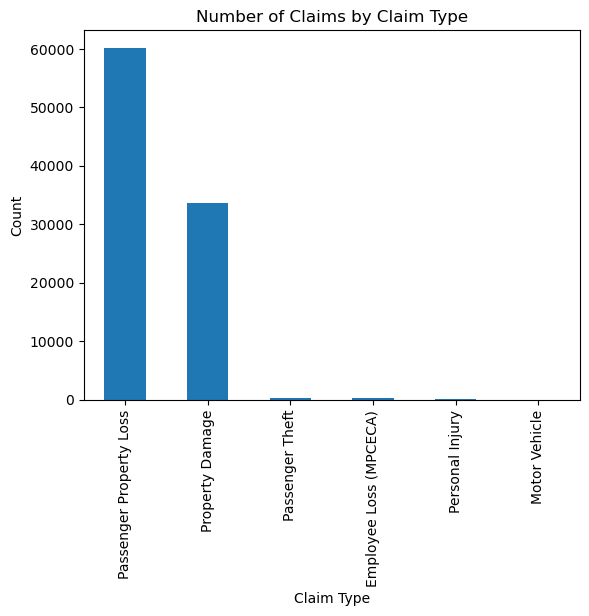

In [81]:
ax = tsa["Claim Type"].value_counts().plot.bar()

ax.set(
    title="Number of Claims by Claim Type",
    xlabel="Claim Type",
    ylabel="Count"
)

Passenger Property Loss is the most common type of insurance claim

# 2.Which claim site within the airport are claims most commonly filed for?

In [82]:
tsa["Claim Site"].value_counts()

Claim Site
Checked Baggage    80448
Checkpoint         14000
Other                280
Motor Vehicle          2
Name: count, dtype: int64

[Text(0.5, 1.0, 'Number of Claims by Claim Site'),
 Text(0.5, 0, 'Claim Site'),
 Text(0, 0.5, 'Count')]

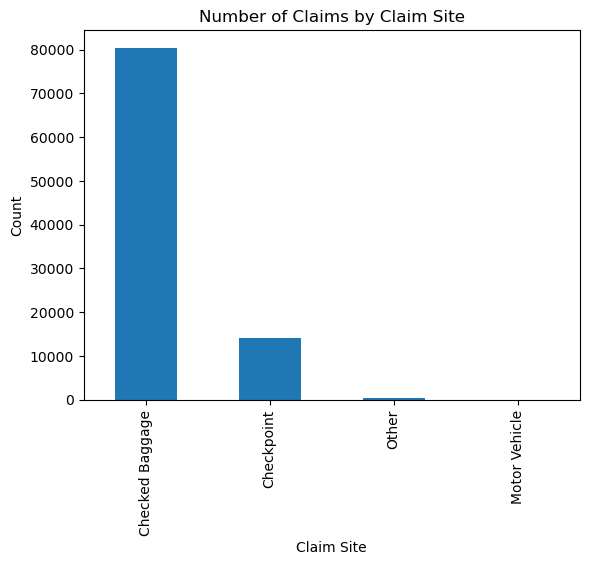

In [83]:
ax = tsa["Claim Site"].value_counts().plot.bar()

ax.set(
    title="Number of Claims by Claim Site",
    xlabel="Claim Site",
    ylabel="Count"
)

Claims are most commonly filed for checked baggage.

# 3.Which claim site within the airport are claims most commonly filed for?

In [84]:
tsa.groupby("Claim Site")["Claim Type"].value_counts()

Claim Site       Claim Type             
Checked Baggage  Passenger Property Loss    53293
                 Property Damage            26493
                 Passenger Theft              294
                 Employee Loss (MPCECA)       275
                 Personal Injury               89
                 Motor Vehicle                  4
Checkpoint       Property Damage             7086
                 Passenger Property Loss     6733
                 Personal Injury              112
                 Passenger Theft               36
                 Employee Loss (MPCECA)        32
                 Motor Vehicle                  1
Motor Vehicle    Passenger Property Loss        2
Other            Passenger Property Loss      159
                 Property Damage              111
                 Personal Injury                7
                 Employee Loss (MPCECA)         1
                 Motor Vehicle                  1
                 Passenger Theft                1
Name: cou

Passenger Property Loss is the most common claim type for Checked Baggage, Other locations, and Motor Vehicle claims. Property Damage is the most common claim type at airport checkpoints.

# 4.What is the typical claim amount? 

In [85]:
tsa["Claim Amount"].describe()

count    9.473000e+04
mean     3.638814e+03
std      5.252705e+05
min      0.000000e+00
25%      6.500000e+01
50%      1.837250e+02
75%      4.809950e+02
max      1.250000e+08
Name: Claim Amount, dtype: float64

[Text(0.5, 1.0, 'Distribution of Claim Amounts'),
 Text(0, 0.5, 'Claim Amount ($)')]

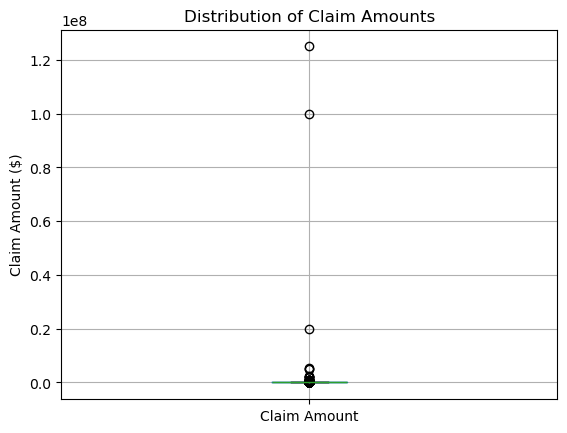

In [86]:
ax = tsa.boxplot(column="Claim Amount")

ax.set(
    title="Distribution of Claim Amounts",
    ylabel="Claim Amount ($)"
)

The boxplot shows several extreme outliers, including very large claim amounts. Because these outliers pull the mean upward, the median is a better measure of the typical claim amount.The typical claim amount is about $183.73 based on the median. 

In [87]:
tsa["Claim Amount"].median()

183.725

# 5.What is the overall claim approval rate for the entire U.S.?

using Disposition column because it has the claim outcome

In [88]:
tsa["Disposition"].value_counts()

Disposition
Deny               53195
Approve in Full    23148
Settle             18387
Name: count, dtype: int64

Approval Rate = Approved + Settled

In [89]:
approved_or_settled = tsa[
    tsa["Disposition"].isin(["Approve in Full", "Settle"])
]

approval_rate = len(approved_or_settled) / len(tsa) * 100

approval_rate

43.84566663147894

The overall claim approval rate is approximately 43.8%. This includes claims that were approved in full or settled, since both outcomes resulted in compensation being paid.

# 6. If a claim is approved or settled, what percent of the claim amount do the airports pay? 

In [90]:
paid_claims = tsa[
    tsa["Disposition"].isin(["Approve in Full", "Settle"])
]

In [91]:
paid_percent = (
    paid_claims["Close Amount"].sum()
    / paid_claims["Claim Amount"].sum()
    * 100
)

paid_percent

np.float64(57.18578879614006)

Airports paid approximately 57.19% of the claimed amount for claims that were approved or settled.

# 7. What are the five airports with the most claims?

In [92]:
# Count claims by airport and display the five airports with the highest number of claims.

tsa["Airport Name"].value_counts().head(5)

Airport Name
Los Angeles International Airport       4492
John F. Kennedy International           3827
Chicago O'Hare International Airport    3619
Newark International Airport            3594
Miami International Airport             2981
Name: count, dtype: int64

[Text(0.5, 1.0, 'Five Airports with the Most Claims'),
 Text(0.5, 0, 'Airport'),
 Text(0, 0.5, 'Number of Claims')]

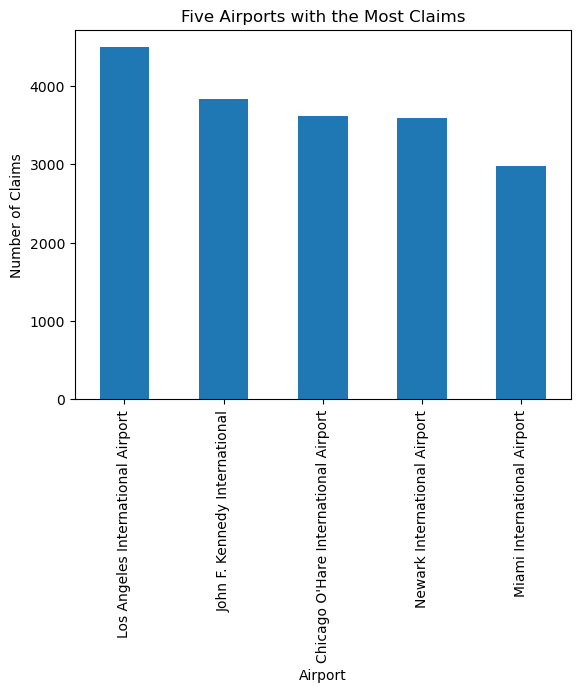

In [93]:
ax = tsa["Airport Name"].value_counts().head(5).plot.bar()

ax.set(
    title="Five Airports with the Most Claims",
    xlabel="Airport",
    ylabel="Number of Claims"
)

# 8.Has the total close amount increased or decreased over time?

In [94]:
# Group claims by year and calculate the total Close Amount to see whether the total amount paid increased or decreased over time.

tsa["Year"] = tsa["Date Received"].dt.year

close_by_year = tsa.groupby("Year")["Close Amount"].sum()

close_by_year

C:\Users\misht\AppData\Local\Temp\ipykernel_21552\489170092.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsa["Year"] = tsa["Date Received"].dt.year


Year
1994         50.00
1996          0.00
2000         85.70
2002      69129.42
2003    1577773.46
2004    2136746.99
2005    1461204.45
2006    1171480.57
2007     836338.11
2008     684528.78
2009     504183.99
2025        100.00
2055          0.00
Name: Close Amount, dtype: float64

In [95]:
# Create a copy to avoid SettingWithCopyWarning
tsa = tsa.copy()

# Extract year from Date Received
tsa["Year"] = tsa["Date Received"].dt.year

# Keep only the years that appear to be valid for this dataset
tsa_valid = tsa[(tsa["Year"] >= 2002) & (tsa["Year"] <= 2009)]

# Calculate total close amount by year
close_by_year = tsa_valid.groupby("Year")["Close Amount"].sum()

close_by_year

Year
2002      69129.42
2003    1577773.46
2004    2136746.99
2005    1461204.45
2006    1171480.57
2007     836338.11
2008     684528.78
2009     504183.99
Name: Close Amount, dtype: float64

[Text(0.5, 1.0, 'Total Close Amount by Year'),
 Text(0.5, 0, 'Year'),
 Text(0, 0.5, 'Total Close Amount ($)')]

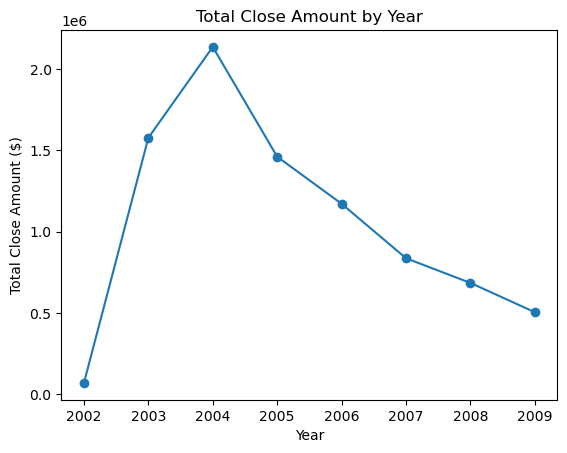

In [96]:
ax = close_by_year.plot.line(marker="o")

ax.set(
    title="Total Close Amount by Year",
    xlabel="Year",
    ylabel="Total Close Amount ($)"
)

The total Close Amount increased sharply from 2002 to 2004, reaching its highest value in 2004. After 2004, the total Close Amount decreased each year through 2009.

# Create a map that shows the location of each airport in the continental U.S. and changes the size of the airport’s dot depending on its number of claims.

In [97]:
airports = pd.read_csv(
    r"C:\Users\misht\Downloads\GlobalAirportDatabase.csv"
)

airports.head()

,ICAOCode,IATACode,AirportName,City,Country,LatitudeDegrees,LatitudeMinutes,LatitudeSeconds,LatitudeDir,LongitudeDegrees,LongitudeMinutes,LongitudeSeconds,LongitudeDirection,Altitude,LatitudeDecimalDegrees,LongitudeDecimalDegrees
0,AYGA,GKA,GOROKA,GOROKA,PAPUA NEW GUINEA,6,4,54,S,145,23,30,E,1610,-6.082,145.392
1,AYLA,LAE,NaN,LAE,PAPUA NEW GUINEA,0,0,0,U,0,0,0,U,0,0.000,0.000
2,AYMD,MAG,MADANG,MADANG,PAPUA NEW GUINEA,5,12,25,S,145,47,19,E,7,-5.207,145.789
3,AYMH,HGU,MOUNT HAGEN,MOUNT HAGEN,PAPUA NEW GUINEA,5,49,34,S,144,17,46,E,1643,-5.826,144.296
4,AYNZ,LAE,NADZAB,NADZAB,PAPUA NEW GUINEA,6,34,11,S,146,43,34,E,73,-6.570,146.726


In [98]:
# Count the number of claims for each airport code

airport_claims = tsa["Airport Code"].value_counts().reset_index()

airport_claims.columns = ["IATACode", "Claim Count"]

airport_claims.head()

,IATACode,Claim Count
0,LAX,4492
1,JFK,3827
2,ORD,3619
3,EWR,3594
4,MIA,2981


In [99]:
airports["Country"].value_counts().head(20)

Country
USA             552
GERMANY         529
FRANCE          472
SOUTH AFRICA    262
CANADA          259
IRAN            256
ZAIRE           249
CHINA           218
INDONESIA       218
NEW ZEALAND     214
RUSSIA          189
INDIA           186
BOLIVIA         180
PERU            171
ITALY           165
SWEDEN          161
ENGLAND         146
ECUADOR         146
ARGENTINA       142
BRAZIL          142
Name: count, dtype: int64

In [100]:
us_airports = airports[airports["Country"] == "UNITED STATES"]

In [123]:
# Standardize airport codes for matching

airport_claims["IATACode"] = (
    airport_claims["IATACode"]
    .str.strip()
    .str.upper()
)

airports["IATACode"] = (
    airports["IATACode"]
    .str.strip()
    .str.upper()
)

In [124]:
us_airports = airports[airports["Country"] == "USA"]

us_airports.shape

(552, 16)

In [125]:
# Combine claim counts with airport latitude and longitude

airport_map_data = pd.merge(
    airport_claims,
    us_airports,
    on="IATACode"
)

airport_map_data.shape

(216, 17)

In [126]:
airport_map_data[[
    "IATACode",
    "AirportName",
    "Claim Count",
    "LatitudeDecimalDegrees",
    "LongitudeDecimalDegrees"
]].head()

,IATACode,AirportName,Claim Count,LatitudeDecimalDegrees,LongitudeDecimalDegrees
0,LAX,LOS ANGELES INTERNATIONAL,4492,33.942,-118.408
1,JFK,JOHN F KENNEDY INTERNATIONAL,3827,40.640,-73.779
2,ORD,CHICAGO OHARE INTERNATIONAL,3619,41.979,-87.904
3,EWR,NEWARK LIBERTY INTERNATIONAL,3594,40.692,-74.169
4,MIA,MIAMI INTERNATIONAL,2981,25.793,-80.291


In [129]:
import geopandas as gpd

gpd.__version__

'1.1.3'

In [130]:
import geopandas as gpd

airport_gdf = gpd.GeoDataFrame(
    airport_map_data,
    geometry=gpd.points_from_xy(
        airport_map_data["LongitudeDecimalDegrees"],
        airport_map_data["LatitudeDecimalDegrees"]
    ),
    crs="EPSG:4326"
)

In [131]:
airport_gdf.head()

,IATACode,Claim Count,ICAOCode,AirportName,City,Country,LatitudeDegrees,LatitudeMinutes,LatitudeSeconds,LatitudeDir,LongitudeDegrees,LongitudeMinutes,LongitudeSeconds,LongitudeDirection,Altitude,LatitudeDecimalDegrees,LongitudeDecimalDegrees,geometry
0,LAX,4492,KLAX,LOS ANGELES INTERNATIONAL,LOS ANGELES,USA,33,56,33,N,118,24,29,W,39,33.942,-118.408,POINT (-118.408 33.942)
1,JFK,3827,KJFK,JOHN F KENNEDY INTERNATIONAL,NEW YORK,USA,40,38,23,N,73,46,44,W,4,40.640,-73.779,POINT (-73.779 40.64)
2,ORD,3619,KORD,CHICAGO OHARE INTERNATIONAL,CHICAGO,USA,41,58,46,N,87,54,16,W,204,41.979,-87.904,POINT (-87.904 41.979)
3,EWR,3594,KEWR,NEWARK LIBERTY INTERNATIONAL,NEWARK,USA,40,41,32,N,74,10,7,W,6,40.692,-74.169,POINT (-74.169 40.692)
4,MIA,2981,KMIA,MIAMI INTERNATIONAL,MIAMI,USA,25,47,35,N,80,17,26,W,3,25.793,-80.291,POINT (-80.291 25.793)


In [132]:
import os

os.listdir(r"C:\Users\misht\Downloads\maps")

['maps', '__MACOSX']

In [133]:
states = gpd.read_file(
    r"C:\Users\misht\Downloads\maps\maps\states.shp"
)

states.head()

,STATE_NAME,DRAWSEQ,STATE_FIPS,SUB_REGION,STATE_ABBR,geometry
0,Hawaii,1,15,Pacific,HI,"MULTIPOLYGON (((-160.0738 22.00418, -160.04971..."
1,Washington,2,53,Pacific,WA,"MULTIPOLYGON (((-122.40202 48.22522, -122.4628..."
2,Montana,3,30,Mountain,MT,"POLYGON ((-111.47543 44.70216, -111.4808 44.69..."
3,Maine,4,23,New England,ME,"MULTIPOLYGON (((-69.77728 44.07415, -69.85993 ..."
4,North Dakota,5,38,West North Central,ND,"POLYGON ((-98.73044 45.93827, -99.00683 45.939..."


Text(0.5, 1.0, 'TSA Insurance Claims by Airport')

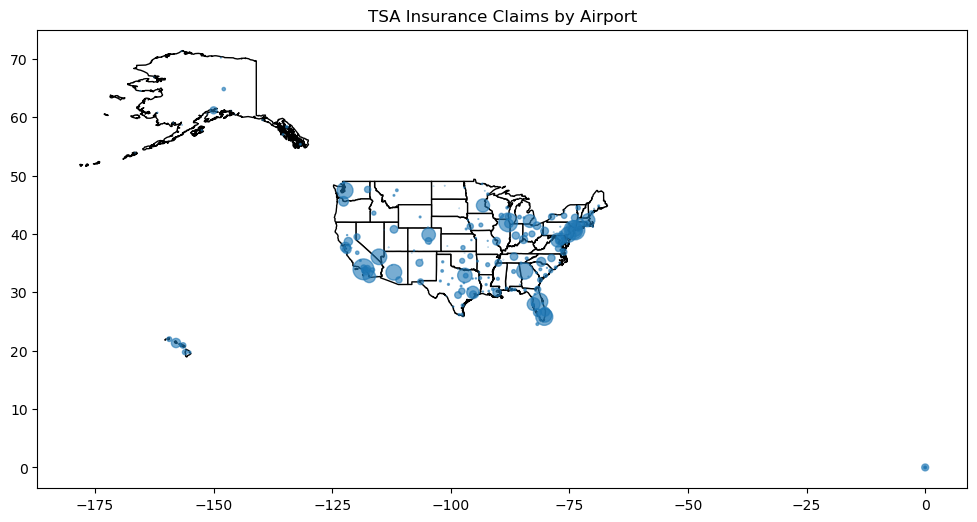

In [134]:
ax = states.plot(
    figsize=(12, 8),
    color="white",
    edgecolor="black"
)

airport_gdf.plot(
    ax=ax,
    markersize=airport_gdf["Claim Count"] / 20,
    alpha=0.6
)

ax.set_title("TSA Insurance Claims by Airport")